In [1]:
!pip install -q umap-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import umap

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving FIFA23_official_data.csv.zip to FIFA23_official_data.csv.zip


In [4]:
file_path = "FIFA23_official_data.csv.zip"

df = pd.read_csv(file_path, compression="zip")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (17660, 29)


In [5]:
df.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN
3,192985,K. De Bruyne,31,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,https://cdn.sofifa.net/flags/be.png,91,91,Manchester City,https://cdn.sofifa.net/teams/10/30.png,...,Yes,"<span class=""pos pos13"">RCM","Aug 30, 2015",NaN,2025,181cm,70kg,€198.9M,17.0,NaN
4,224232,N. Barella,25,https://cdn.sofifa.net/players/224/232/23_60.png,Italy,https://cdn.sofifa.net/flags/it.png,86,89,Inter,https://cdn.sofifa.net/teams/44/30.png,...,Yes,"<span class=""pos pos13"">RCM","Sep 1, 2020",NaN,2026,172cm,68kg,€154.4M,23.0,NaN


In [6]:
print(df.columns.tolist())

['ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special', 'Preferred Foot', 'International Reputation', 'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Joined', 'Loaned From', 'Contract Valid Until', 'Height', 'Weight', 'Release Clause', 'Kit Number', 'Best Overall Rating']


In [7]:
features = [
    "Age",
    "Overall",
    "Potential",
    "Special",
    "International Reputation",
    "Weak Foot",
    "Skill Moves"
]

X = df[features].copy()

print("Selected Features:")
print(features)

print("\nShape of selected data:", X.shape)

Selected Features:
['Age', 'Overall', 'Potential', 'Special', 'International Reputation', 'Weak Foot', 'Skill Moves']

Shape of selected data: (17660, 7)


In [8]:
print("Missing values before handling:")
print(X.isnull().sum())

Missing values before handling:
Age                         0
Overall                     0
Potential                   0
Special                     0
International Reputation    0
Weak Foot                   0
Skill Moves                 0
dtype: int64


In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (17660, 7)
Scaled shape: (17660, 7)


In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed successfully!")
print("PCA output shape:", X_pca.shape)

PCA completed successfully!
PCA output shape: (17660, 2)


In [11]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", explained_variance[0])
print("Explained variance by PC2:", explained_variance[1])

print("Total explained variance:",
      explained_variance.sum())

Explained variance by PC1: 0.48031791915280087
Explained variance by PC2: 0.16503137303186927
Total explained variance: 0.6453492921846702


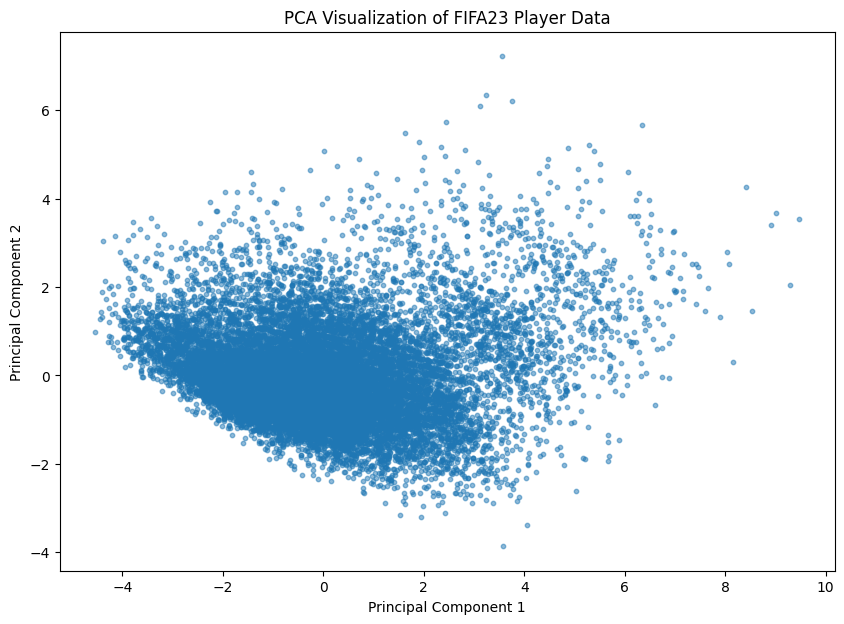

In [12]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of FIFA23 Player Data")

plt.show()

In [14]:
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

print("UMAP completed successfully!")
print("UMAP output shape:", X_umap.shape)

UMAP completed successfully!
UMAP output shape: (17660, 2)


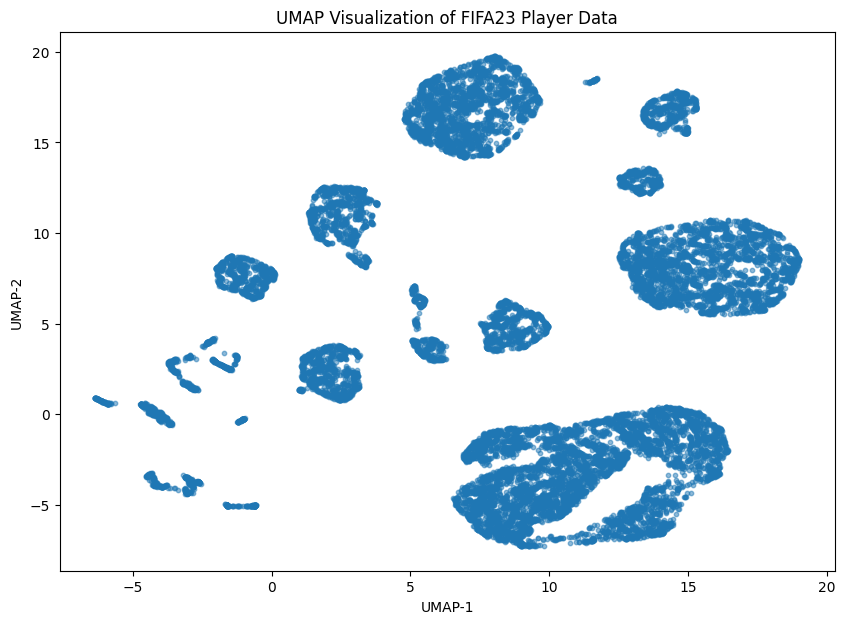

In [15]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=10,
    alpha=0.5
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Visualization of FIFA23 Player Data")

plt.show()

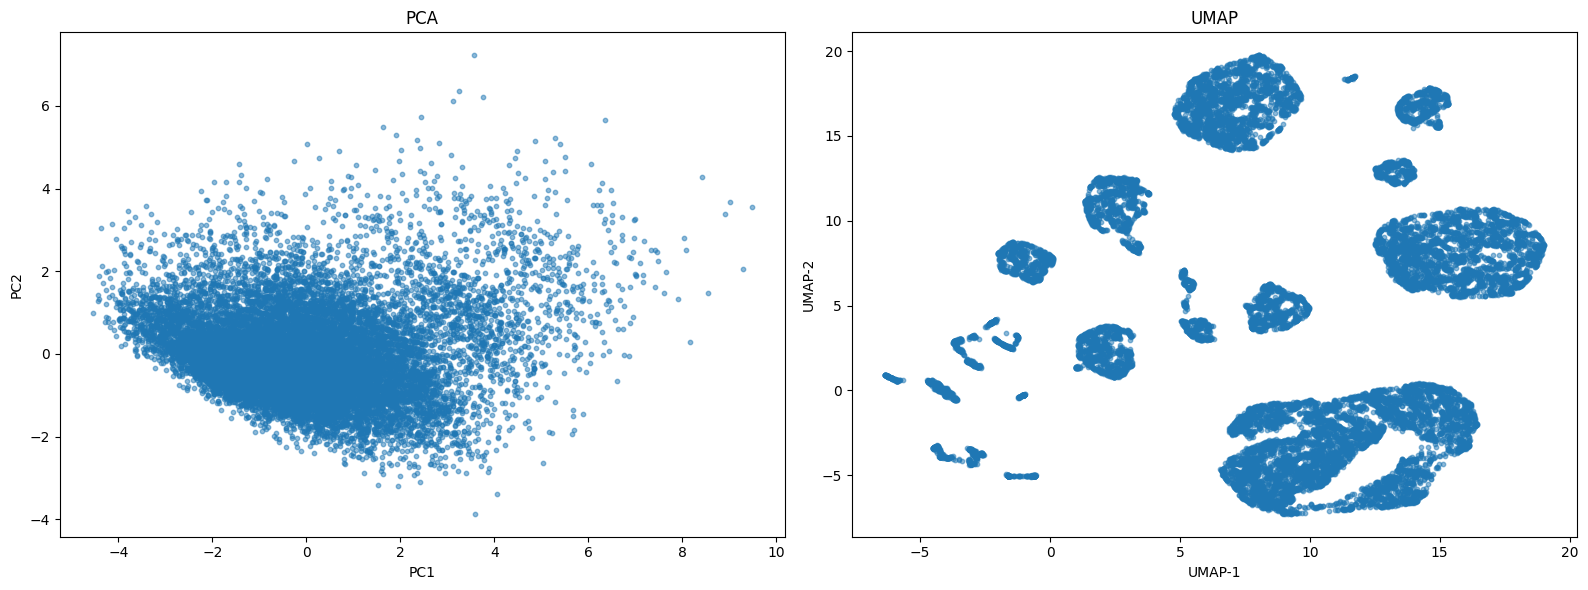

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.5
)

axes[0].set_title("PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# UMAP
axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=10,
    alpha=0.5
)

axes[1].set_title("UMAP")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

In [17]:
results = df[["ID", "Name", "Age", "Overall", "Potential"]].copy()

results["PCA_1"] = X_pca[:, 0]
results["PCA_2"] = X_pca[:, 1]

results["UMAP_1"] = X_umap[:, 0]
results["UMAP_2"] = X_umap[:, 1]

results.head()

,ID,Name,Age,Overall,Potential,PCA_1,PCA_2,UMAP_1,UMAP_2
0,209658,L. Goretzka,27,87,88,6.985089,1.942269,-0.606587,-5.035972
1,212198,Bruno Fernandes,27,86,87,6.185816,0.976431,-3.064759,-3.498765
2,224334,M. Acuña,30,85,85,4.903523,0.881179,-3.771830,-0.199114
3,192985,K. De Bruyne,31,91,91,8.535862,1.466011,-0.583287,-5.025779
4,224232,N. Barella,25,86,89,5.645065,1.079796,-2.962525,-3.770996


In [18]:
results.to_csv(
    "FIFA23_PCA_UMAP_Results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
